# 6.6 LSA

In [2]:
import pandas as pd
import re
import nltk
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from gensim import corpora
from gensim.models import LsiModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

[nltk_data] Downloading package wordnet to /Users/rolando/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Load Data

In [3]:
data = pd.read_csv("news_articles.csv")

In [4]:
data.head()

,id,title,content
0,25626,"One Weight-Loss Approach Fits All? No, Not Eve...","Dr. Frank Sacks, a professor of nutrition at H..."
1,19551,South Carolina Stuns Baylor to Reach the Round...,South Carolina’s win over Duke was not only ...
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Yo...",(Want to get this briefing by email? Here’s th...
3,18026,"His Predecessor Gone, Gambia’s New President F...","BANJUL, Gambia — A week after he was inaugu..."
4,21063,‘Harry Potter and the Cursed Child’ Goes From ...,The biggest book of the summer isn’t a blockbu...


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       100 non-null    int64 
 1   title    100 non-null    object
 2   content  100 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


### Clean Data

In [6]:
# take just the content of the article, lowercase and remove punctuation
articles = data['content'].str.lower().apply(lambda x: re.sub(r"([^\w\s])", "", x))

In [7]:
# stop word removal
en_stopwords = stopwords.words('english')
articles = articles.apply(lambda x: ' '.join([word for word in x.split() if word not in (en_stopwords)]))

In [8]:
# tokenize
articles = articles.apply(lambda x: word_tokenize(x))

In [9]:
# lemmatize before we replace articles with their stemmed version
lemmatizer = WordNetLemmatizer()
lem_articles = articles.apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

# stemming (done for speed as we have a lot of text)
ps = PorterStemmer()
articles = articles.apply(lambda tokens: [ps.stem(token) for token in tokens])

In [10]:
articles

0     [dr, frank, sack, professor, nutrit, harvard, ...
1     [south, carolina, win, duke, surpris, fan, pos...
2     [want, get, brief, email, here, good, even, he...
3     [banjul, gambia, week, inaugur, anoth, countri...
4     [biggest, book, summer, isnt, blockbust, thril...
                            ...                        
95    [want, get, brief, email, here, good, even, he...
96    [tallinn, estonia, guard, brought, ahm, abdul,...
97    [gov, scott, walker, wisconsin, activ, wiscons...
98    [social, media, shook, emot, headlin, shout, n...
99    [moment, joanna, acevedo, first, set, foot, bo...
Name: content, Length: 100, dtype: object

### Vectorization

In [11]:
# create dictionary of all words
dictionary = corpora.Dictionary(articles)
print(dictionary)

lem_dictionary = corpora.Dictionary(lem_articles)

Dictionary<8693 unique tokens: ['10', '100', '108', '15', '155']...>


In [12]:
# vecotize using bag of words into a document term matrix
doc_term = [dictionary.doc2bow(text) for text in articles]
lem_doc_term = [dictionary.doc2bow(text) for text in lem_articles]

In [14]:
print(lem_doc_term)

[[(0, 1), (1, 1), (2, 1), (3, 2), (4, 1), (5, 1), (6, 1), (7, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 2), (15, 1), (16, 1), (17, 2), (18, 1), (19, 1), (20, 3), (21, 3), (22, 1), (23, 3), (24, 2), (25, 4), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (39, 1), (42, 1), (43, 1), (44, 1), (46, 1), (47, 2), (48, 2), (49, 1), (50, 1), (51, 2), (52, 1), (54, 2), (57, 6), (58, 1), (62, 2), (65, 2), (66, 1), (69, 1), (71, 4), (74, 1), (78, 2), (79, 2), (82, 1), (84, 1), (85, 1), (87, 3), (88, 1), (90, 1), (93, 6), (94, 1), (96, 1), (98, 1), (99, 1), (100, 1), (101, 1), (102, 1), (103, 2), (104, 4), (106, 1), (108, 1), (109, 3), (111, 1), (112, 2), (113, 2), (114, 2), (115, 3), (118, 1), (120, 1), (121, 1), (122, 1), (125, 1), (126, 3), (132, 5), (133, 2), (137, 2), (138, 1), (139, 1), (143, 1), (144, 1), (145, 1), (146, 1), (147, 1), (149, 1), (153, 1), (155, 2), (161, 2), (163, 1), (166, 4), (169, 1), (170, 1), (172, 2), (173, 1), (176,

### LSA

In [15]:
# specify number of topics
num_topics = 2

In [16]:
# create LSA model
lsamodel = LsiModel(doc_term, num_topics=num_topics, id2word = dictionary) 
print(lsamodel.print_topics(num_topics=num_topics, num_words=5))

lem_lsamodel = LsiModel(lem_doc_term, num_topics=num_topics, id2word = lem_dictionary)
print(lem_lsamodel.print_topics(num_topics=num_topics, num_words=5)) 

[(0, '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'), (1, '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight"')]
[(0, '0.688*"lose" + 0.458*"principle" + 0.210*"intermarriage" + 0.135*"glimmering" + 0.127*"sword"'), (1, '-0.476*"lose" + 0.358*"principle" + -0.327*"intermarriage" + 0.322*"48" + 0.186*"virginal"')]


### Determine Number of Topics

In [18]:
# generate coherence scores to determine an optimum number of topics
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics+1):
    model = LsiModel(doc_term, num_topics=num_topics_i, id2word = dictionary, random_seed=0)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=articles, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())

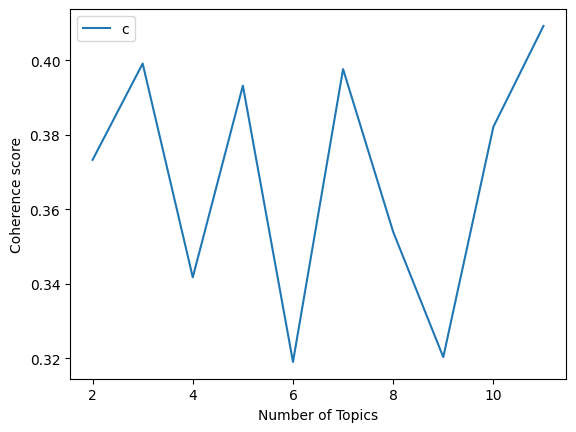

In [19]:
plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [17]:
final_n_topics = 3
lsamodel_f = LsiModel(doc_term, num_topics=final_n_topics, id2word = dictionary) 
print(lsamodel_f.print_topics(num_topics=final_n_topics, num_words=5))

[(0, '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'), (1, '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight"'), (2, '0.460*"saudi" + 0.264*"taliban" + -0.249*"weight" + 0.194*"afghanistan" + -0.191*"dr"')]
